In [ ]:

!pip install seaborn scikit-learn pandas matplotlib


In [17]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.tree import plot_tree



import warnings
warnings.filterwarnings("ignore")


In [2]:

# Dataset de clasificación: Diabetes
diabetes = fetch_openml(name="diabetes", version=1, as_frame=True)
df = diabetes.frame

# Dividir
X = df.drop(columns="class")
y = df["class"]
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=24)


In [ ]:
# Entrenamos dos árboles: uno sin podar, otro podado
# Entrenar árbol sin podar (max_depth=None, es decir, sin límite de profundidad)
# Entrenamiento de árboles con poda usando GridSearchCV para seleccionar el mejor max_depth

from sklearn.model_selection import GridSearchCV

# Definir la grilla de valores de profundidad máxima a probar
# max_depth es el hiperparámetro que poda el árbol limitando la cantidad de niveles que puede crecer
param_grid = {'max_depth': range(1, 11)}

# GridSearch con validación cruzada (5-fold)
grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=24),
    param_grid=param_grid,
    cv=5
)

# Ajustar el modelo y encontrar el mejor max_depth
grid_search.fit(X_train, y_train)
best_depth = grid_search.best_params_['max_depth']
print(f"Mejor max_depth encontrado por GridSearchCV: {best_depth}")

# Entrenar árbol sin poda
tree = DecisionTreeClassifier(random_state=24)
tree.fit(X_train, y_train)

# Entrenar árbol podado con el mejor max_depth
tree_pruned = DecisionTreeClassifier(max_depth=best_depth, random_state=24)
tree_pruned.fit(X_train, y_train)

# Guardamos los modelos en un diccionario para evaluación posterior
models = {'Modelo 1': tree, 'Modelo 2 (Podado)': tree_pruned}



Modelo 1
                 precision    recall  f1-score   support

tested_negative       0.76      0.79      0.77       100
tested_positive       0.58      0.54      0.56        54

       accuracy                           0.70       154
      macro avg       0.67      0.66      0.67       154
   weighted avg       0.70      0.70      0.70       154



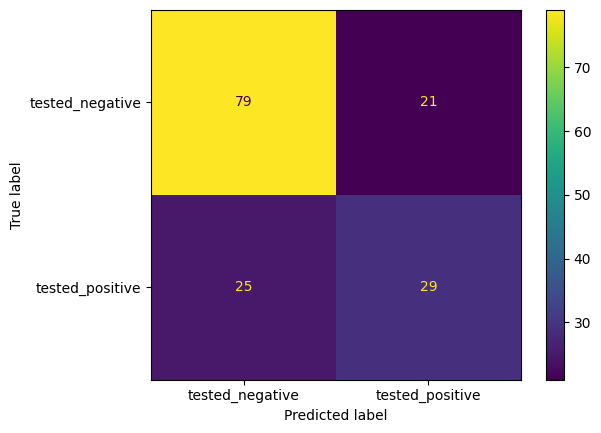

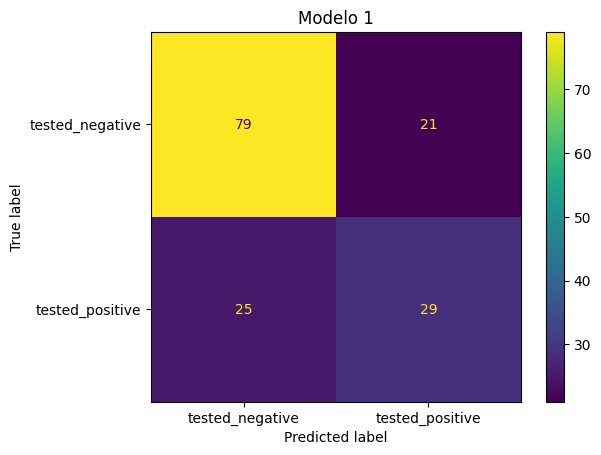


Modelo 2 (Podado)
                 precision    recall  f1-score   support

tested_negative       0.80      0.82      0.81       100
tested_positive       0.65      0.63      0.64        54

       accuracy                           0.75       154
      macro avg       0.73      0.72      0.73       154
   weighted avg       0.75      0.75      0.75       154



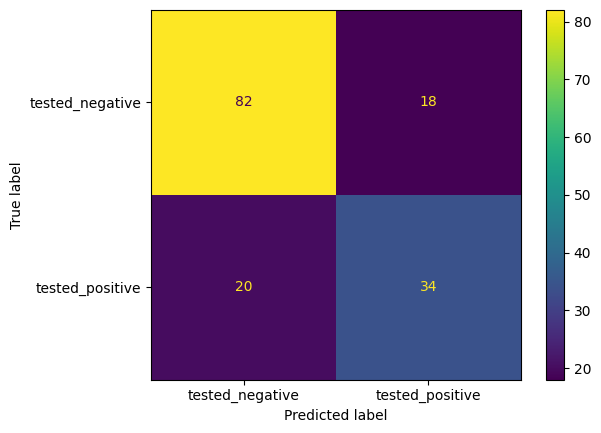

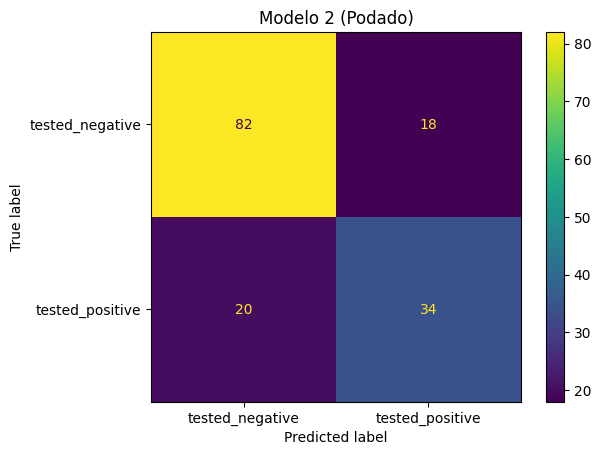

In [27]:

for name, model in models.items():
    pred = model.predict(X_test)
    print(f"\n{name}")
    print(classification_report(y_test, pred))
    ConfusionMatrixDisplay.from_estimator(model, X_test, y_test).plot()
    plt.title(name)
    plt.show()


In [6]:

# Dataset de regresión: Boston Housing
from sklearn.datasets import fetch_openml
boston = fetch_openml(name="boston", version=1, as_frame=True)
df_boston = boston.frame

# División
Xr = df_boston.drop(columns="MEDV")
yr = df_boston["MEDV"]
Xr_train, Xr_test, yr_train, yr_test = train_test_split(Xr, yr, test_size=0.2, random_state=46)


In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV

# Definir la grilla de valores de profundidad máxima a probar
# max_depth es el hiperparámetro que poda el árbol limitando la cantidad de niveles que puede crecer
param_grid_r = {'max_depth': range(1, 11)}

# GridSearchCV para encontrar el mejor max_depth con validación cruzada
grid_search_r = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=46),
    param_grid=param_grid_r,
    cv=5,
    scoring='neg_mean_squared_error'  # o 'r2'
)

grid_search_r.fit(Xr_train, yr_train)
best_depth_r = grid_search_r.best_params_['max_depth']
print(f"Mejor max_depth encontrado para regresión: {best_depth_r}")

# Entrenar modelos definitivos
mod1 = DecisionTreeRegressor(random_state=46)  # sin poda
mod1.fit(Xr_train, yr_train)

mod2 = DecisionTreeRegressor(max_depth=best_depth_r, random_state=46)  # podado
mod2.fit(Xr_train, yr_train)

# Diccionario de modelos de regresión
modelos_r = {"Modelo 1": mod1, "Modelo 2 (Podado)": mod2}


In [30]:

def evaluar_modelo(y_true, y_pred):
    e = y_true - y_pred
    bias = np.mean(e)
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return pd.Series({'bias': bias, 'mse': mse, 'mae': mae, 'rmse': rmse, 'r2': r2})

resultados = {}
for nombre, modelo in modelos_r.items():
    pred = modelo.predict(Xr_test)
    resultados[nombre] = evaluar_modelo(yr_test, pred)

pd.DataFrame(resultados)


,Modelo 1,Modelo 2 (Podado)
bias,-0.285294,-0.167846
mse,25.157941,20.016943
mae,3.330392,2.852705
rmse,5.015769,4.474030
r2,0.612007,0.691293


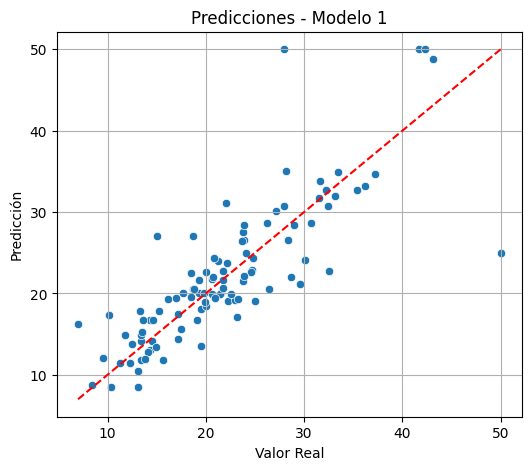

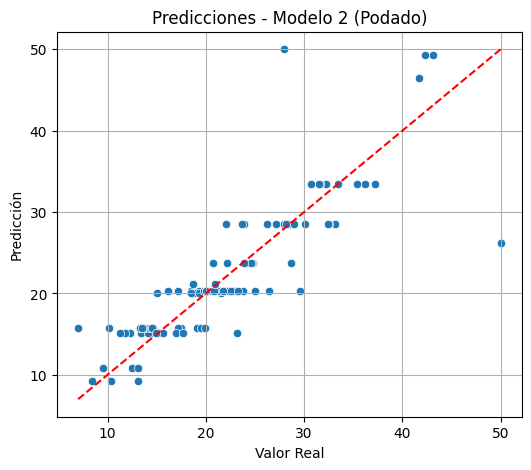

In [31]:

for nombre, modelo in modelos_r.items():
    pred = modelo.predict(Xr_test)
    plt.figure(figsize=(6, 5))
    sns.scatterplot(x=yr_test, y=pred)
    plt.plot([yr_test.min(), yr_test.max()], [yr_test.min(), yr_test.max()], '--', color='red')
    plt.xlabel("Valor Real")
    plt.ylabel("Predicción")
    plt.title(f"Predicciones - {nombre}")
    plt.grid(True)
    plt.show()


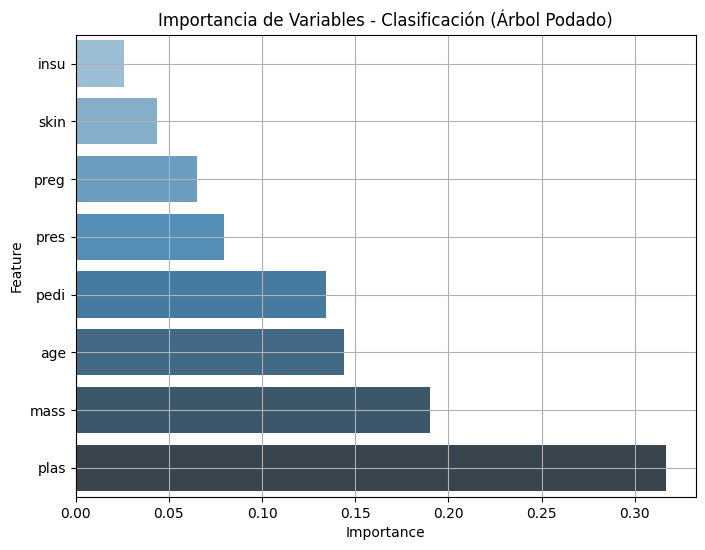

In [15]:

# Importancia de variables - Clasificación (modelo podado)
importances = tree_pruned.feature_importances_
features = X.columns
imp_df = pd.DataFrame({'Feature': features, 'Importance': importances})
imp_df = imp_df.sort_values(by='Importance', ascending=True)

plt.figure(figsize=(8, 6))
sns.barplot(x='Importance', y='Feature', data=imp_df, palette='Blues_d')
plt.title("Importancia de Variables - Clasificación (Árbol Podado)")
plt.grid(True)
plt.show()


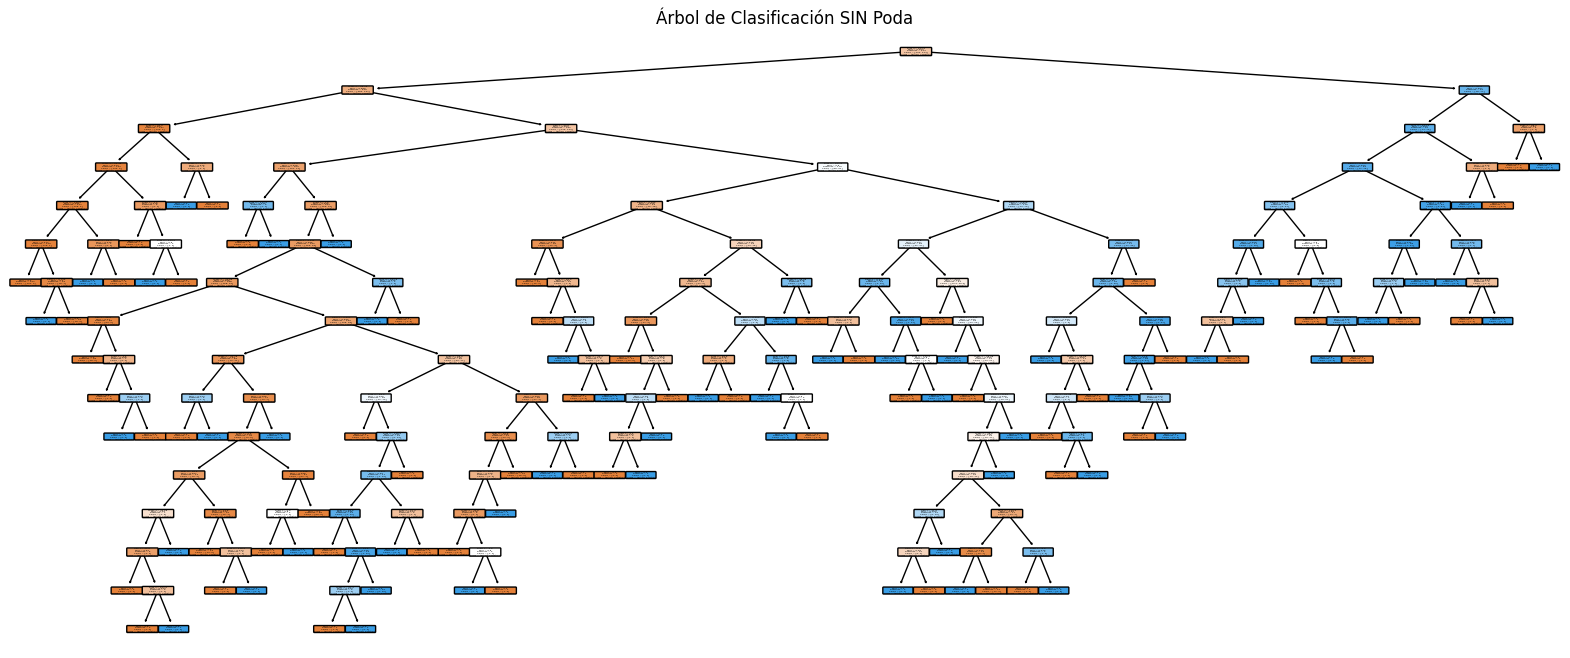

In [39]:
# Visualizar el árbol SIN podar - Clasificación
plt.figure(figsize=(20, 8))
plot_tree(tree, feature_names=X.columns, class_names=tree.classes_, filled=True, rounded=True)
plt.title("Árbol de Clasificación SIN Poda")
plt.show()


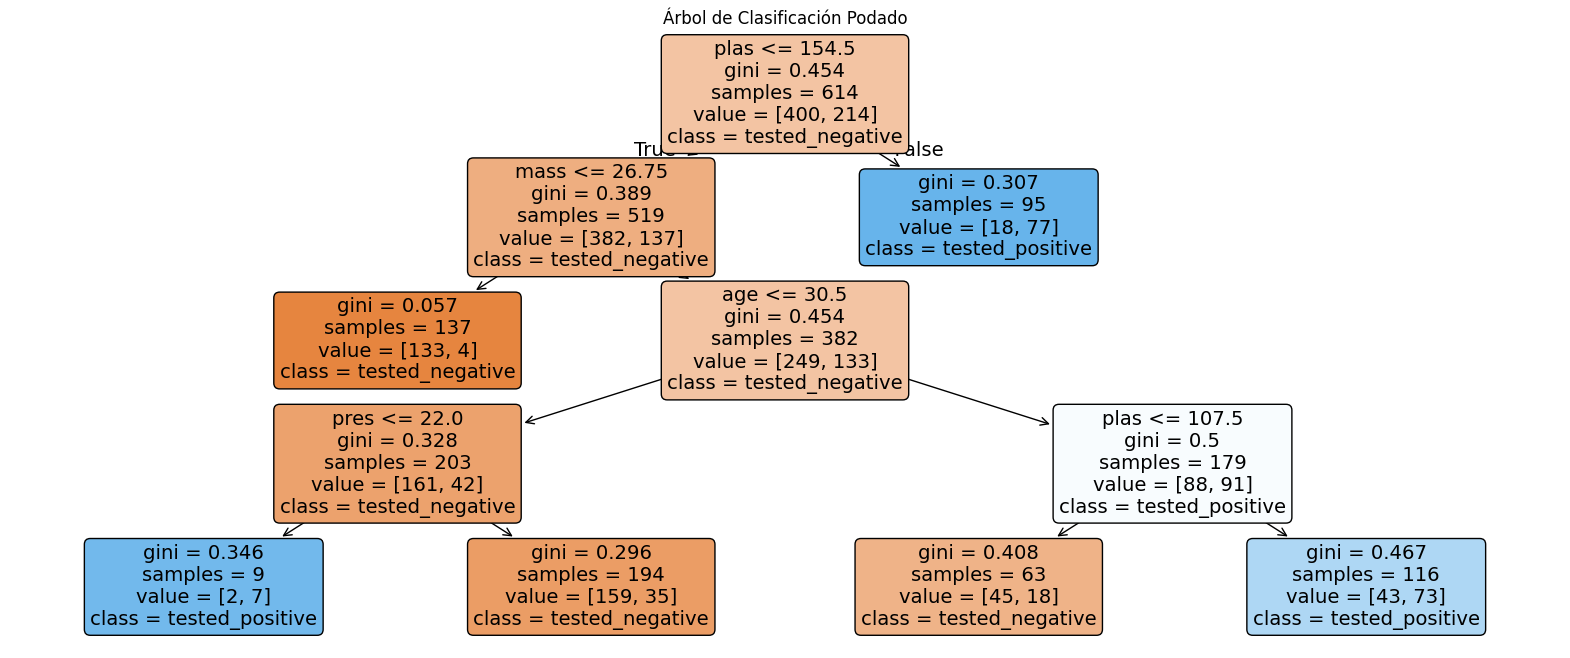

In [37]:

# Visualizar el árbol podado - Clasificación
plt.figure(figsize=(20, 8))
plot_tree(tree_pruned, feature_names=X.columns, class_names=tree_pruned.classes_, filled=True, rounded=True)
plt.title("Árbol de Clasificación Podado")
plt.show()


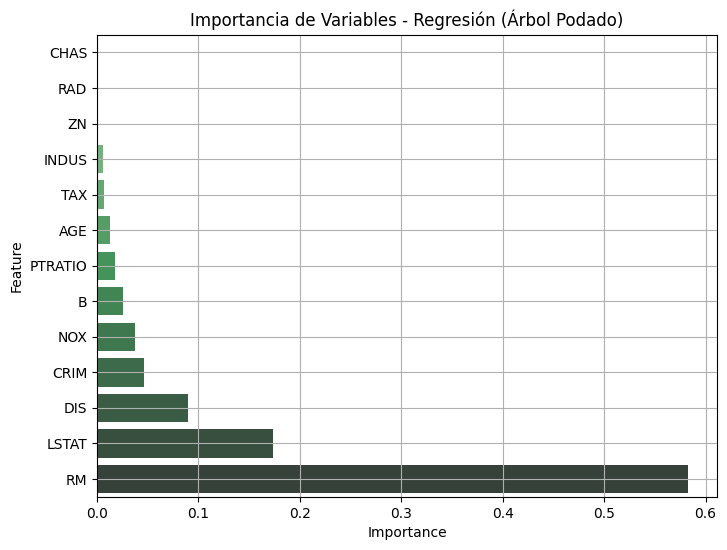

In [19]:

# Importancia de variables - Regresión (modelo podado)
importances = mod2.feature_importances_
features = Xr.columns
imp_df_r = pd.DataFrame({'Feature': features, 'Importance': importances})
imp_df_r = imp_df_r.sort_values(by='Importance', ascending=True)

plt.figure(figsize=(8, 6))
sns.barplot(x='Importance', y='Feature', data=imp_df_r, palette='Greens_d')
plt.title("Importancia de Variables - Regresión (Árbol Podado)")
plt.grid(True)
plt.show()


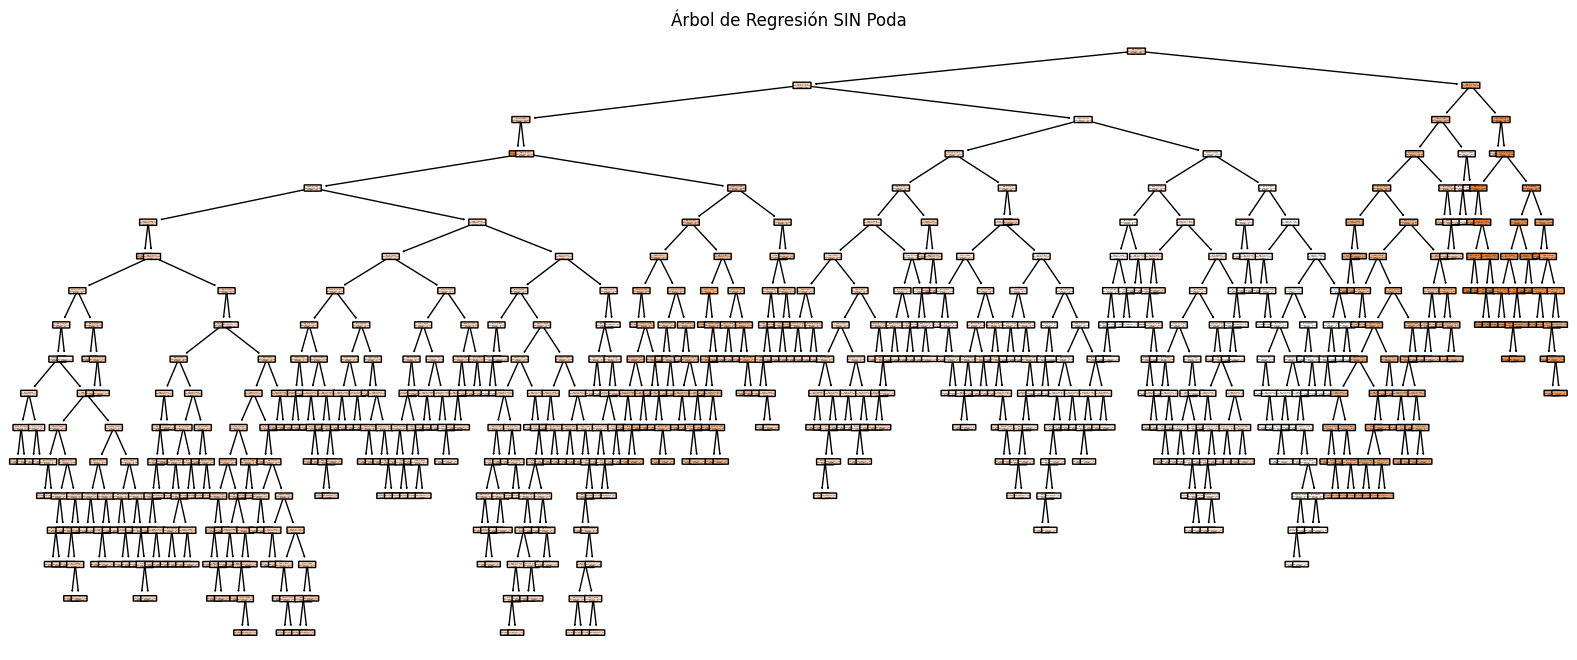

In [40]:
# Visualizar el árbol SIN podar - Regresión
plt.figure(figsize=(20, 8))
plot_tree(mod1, feature_names=Xr.columns, filled=True, rounded=True)
plt.title("Árbol de Regresión SIN Poda")
plt.show()


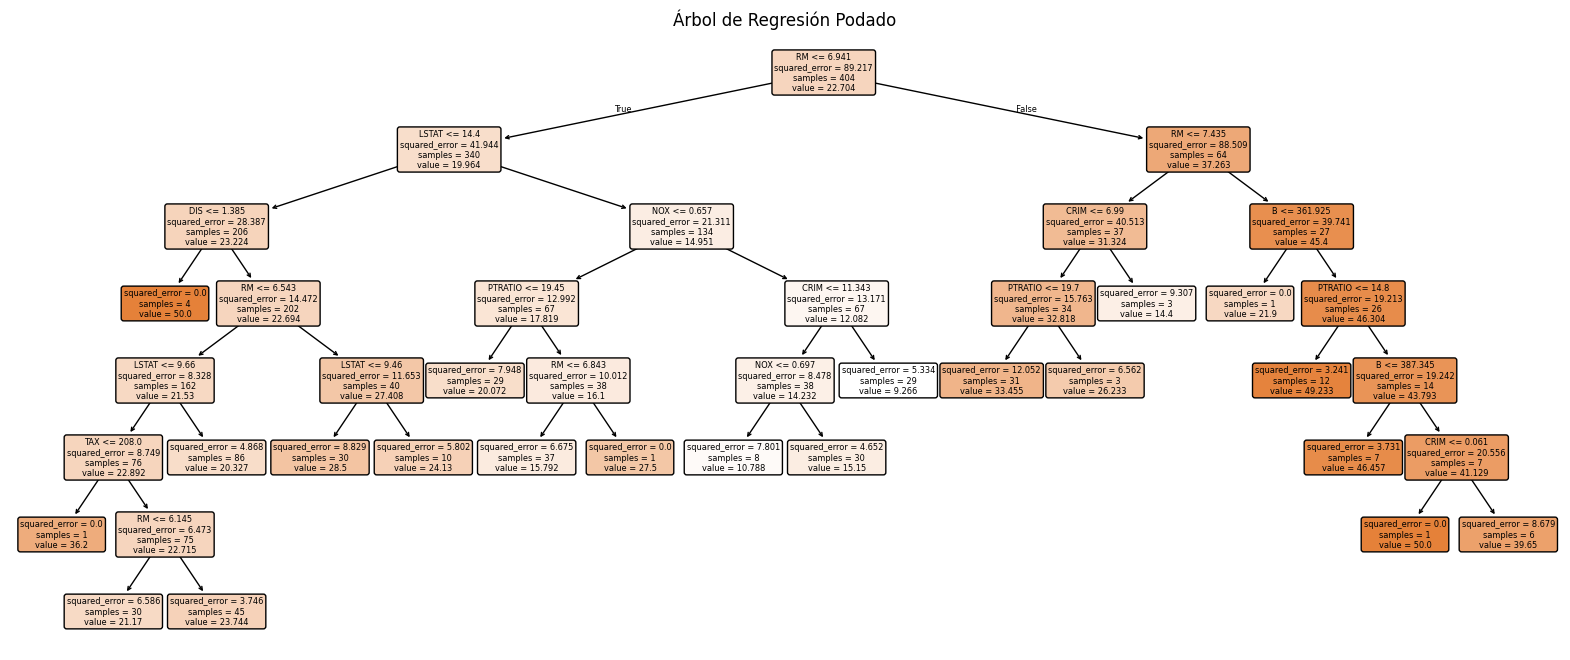

In [38]:

# Visualizar el árbol podado - Regresión
plt.figure(figsize=(20, 8))
plot_tree(mod2, feature_names=Xr.columns, filled=True, rounded=True)
plt.title("Árbol de Regresión Podado")
plt.show()
